In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D


In [12]:
print(os.listdir("/content"))
print(os.listdir("/content/processed_images"))
print(os.listdir("/content/processed_images/train"))
print(os.listdir("/content/processed_images/test"))


['.config', 'processed_images', 'cataract.zip', 'sample_data']
['train', 'test']
['normal', 'cataract']
['normal', 'cataract']


In [13]:
train_dir = "/content/processed_images/train"
test_dir  = "/content/processed_images/test"


In [14]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)


Found 491 images belonging to 2 classes.
Found 121 images belonging to 2 classes.


In [15]:
train_data.class_indices


{'cataract': 0, 'normal': 1}

In [16]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze pretrained layers

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 66s 4s/step - accuracy: 0.6136 - loss: 0.8299 - val_accuracy: 0.9256 - val_loss: 0.1804
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.8942 - loss: 0.2561 - val_accuracy: 0.9339 - val_loss: 0.1506
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.9232 - loss: 0.1638 - val_accuracy: 0.9339 - val_loss: 0.1374
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9407 - loss: 0.1549 - val_accuracy: 0.9421 - val_loss: 0.1214
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.9423 - loss: 0.1522 - val_accuracy: 0.9174 - val_loss: 0.2015
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9191 - loss: 0.1877 - val_accuracy: 0.9421 - val_loss: 0.1220
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9629 - loss: 0.1144 - val_accuracy: 0.9339 - val_loss: 0.1060
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.9622 - loss: 0.1155 - val_accuracy: 0.9421 - val_loss:

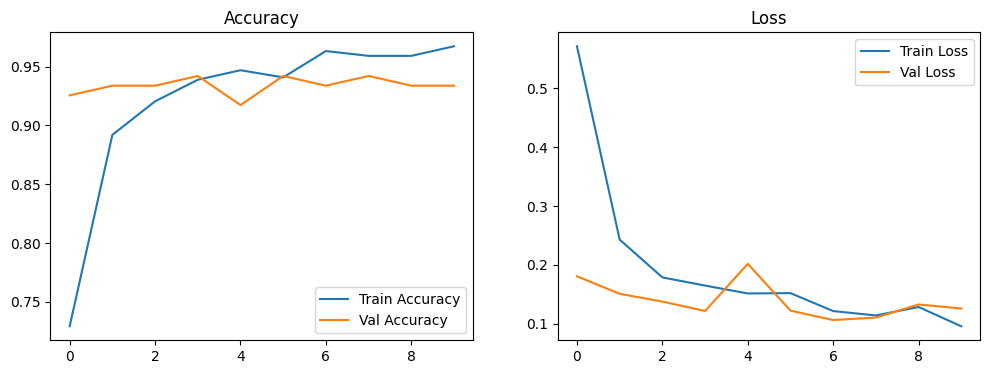

In [18]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()


In [19]:
model.save("cataract_detection_mobilenet.h5")


In [21]:
from tensorflow.keras.preprocessing import image

img_path = "/content/processed_images/test/cataract/image_246.png"

img = image.load_img(img_path, target_size=img_size)
img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Normal Eye")
else:
    print("Cataract Detected")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Cataract Detected
